In [2]:
import os
import sys
import glob

path = os.path.abspath("")
splitted = path.split(os.sep)
user_independent = os.path.join(
    splitted[0] + os.sep, splitted[1], splitted[2], splitted[3]
)
src_path = os.path.join(user_independent, "GitHub", "Photoswitching")
sys.path.append(src_path)

import src.blinking as bl
import src.distributions as dist
import src.emissions as em
import src.fcs as fcs_p
import src.figure as fi
import src.fluorophores as fl
import src.formulas as fo
import src.miscellaneous as mi
import src.network as net
import src.simulation as si
import src.prediction as pr
import src.analysis as an
import src.transitions as tr
import src.routines as ro

import numpy as np
import pandas as pd

%load_ext autoreload
%autoreload 2

import warnings


def custom_warning_format(msg, category, filename, lineno, line=None):
    if line is None:
        import linecache

        line = linecache.getline(filename, lineno)
    return f"WARNING for line: {line} {msg} \n"


warnings.formatwarning = custom_warning_format

In [2]:
def prepare_transition_set_ofret(number_fluorophores, distance):
    fluorophores = fl.construct_fluorophores(
    name="cy5_dna", distance=distance, count=number_fluorophores, shape="square"
    )
    fluorophore_system = fl.FluorophoreSystem(fluorophores=fluorophores)

    transitions = fluorophore_system.load_transitions(
    summarize=True,
    irradiance=5,
    wavelength=640,
    bleaching=True,
    energy_transfer=True,
    dstorm=True,
    dstorm_parameters={'reducing_agent':'mea',
    'concentration':100,
    'ph':7.5},
    energy_transfer_parameters={'overwrite': {'off': [1, 0.0001]}, 
                                'exclude': ['s0']}
    )
    transition_set = tr.TransitionSet(transitions, fluorophore_system)
    transition_set.finalize()

    return transition_set


In [ ]:
distances = [3, 6, 9, 18]
for distance in distances:
    transition_set = prepare_transition_set_ofret(2, distance)
    fingerprint_data, bleaching_times_all_runs = \
        ro.fingerprint_analysis(transition_set, batch_size=80, batches=1, # 900 min
                                filepath=r"D:\simulation_data\oet_variations\r100%eff001%2f", 
                                filename=f"{distance}nm", seed=1, use_memmap=r"C:\Users\vie43sq\Desktop\memmaps\run_1")

### Reading the data

In [3]:
distances = [3, 6, 9, 18]
identifiers = [f"{distance}nm" for distance in distances]
bleaching_times_all = []
fingerprints_all = []
fingerprints_discard = []

for _ in identifiers:
    fingerprints_all.append(pd.Series(np.zeros(300001), 
                                      np.round(np.linspace(0, 300, 300001), decimals=12), 
                                      dtype=np.int32))
    fingerprints_discard.append(pd.Series(np.zeros(299001), 
                                      np.round(np.linspace(1, 300, 299001), decimals=12), 
                                      dtype=np.int32))
folder_path = r"D:\simulation_data\oet_variations\r100%eff001%2f"
for file in glob.glob(folder_path + "/*"):
    if file.endswith(".npy"):
        bleaching_times_all.append(np.load(file))
    elif file.endswith(".parquet"):
        for id in identifiers:
            if id in file:
                fingerprints_all[identifiers.index(id)] += pd.read_parquet(file).sum(axis=1)
                fingerprints_discard[identifiers.index(id)] += pd.read_parquet(file).iloc[1000:].sum(axis=1)
                break

for i, (fingerprint, fingerprint_discard) in enumerate(zip(fingerprints_all, fingerprints_discard)):
    fingerprint = fingerprint.cumsum() / fingerprint.sum()
    fingerprints_all[i] = fingerprint
    fingerprint_discard = fingerprint_discard.cumsum() / fingerprint_discard.sum()
    fingerprints_discard[i] = fingerprint_discard

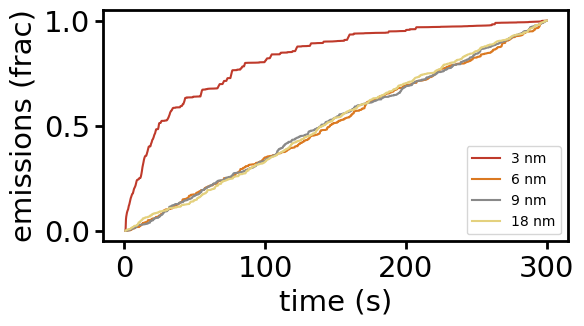

In [8]:
axes = fi.universal_figure()
colors = ['#BF3A2B', '#DB7921', '#898989', '#E4D17E']
for i, (fingerprint, distance) in enumerate(zip(fingerprints_discard, distances)):
    fi.universal_figure(data=[fingerprint.index, fingerprint.values], 
                        axes=axes[0, 0], 
                        ylabel=r'emissions (frac)', xlabel='time (s)', label=f'{distance} nm',
                        legend=True, color=colors[i])  
fig = mi.get_figure(axes)
fig.savefig("r100eff0012f.svg")  

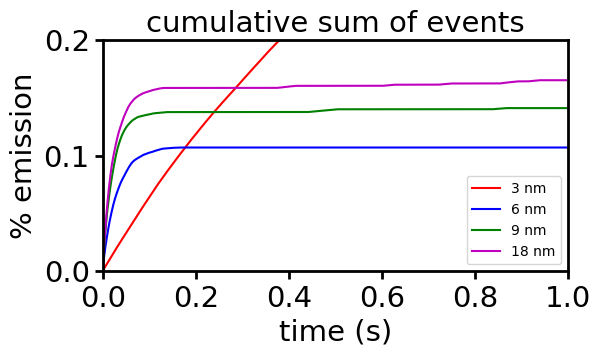

In [16]:
axes = fi.universal_figure()
colors = ['r', 'b', 'g', 'm']
for i, (fingerprint, distance) in enumerate(zip(fingerprints_all, distances)):
    fi.universal_figure(data=[fingerprint.index, fingerprint.values], 
                        axes=axes[0, 0], title='cumulative sum of events', 
                        ylabel='% emission', xlabel='time (s)', label=f'{distance} nm',
                        legend=True, color=colors[i], xlim=[0, 1], ylim=[0, 0.2])    